# Breast Cancer Veri Seti ile Başlangıç

Bu notebook, ödevin ilk aşaması için başlangıç seviyesinde hazırlandı. Amacımız veri setini yüklemek, tabloyu
görmek, kolonları incelemek ve temel yapısını anlamak.


## 1. Veri Setinin Yüklenmesi

Bu bölümde veri setini önce adım adım inceleyip sonra bölüm sonunda tek parça çalışan kod ile toparlıyoruz.

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer


In [ ]:
dataset = load_breast_cancer()

print(type(dataset))
print(dataset.keys())

print(dataset.data[:5])

İlk adımda veri setinin yapısını ham hâliyle gördük. Böylece elimizde nasıl bir nesne olduğunu ve veri seti
içinde hangi alanların bulunduğunu anlamış olduk.


## 1.1 DataFrame'e Dönüştürme

In [ ]:
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name='target')

## 1.2 İlk Gözlemler ve Boyut Bilgisi

In [ ]:
print('Satır ve sütun sayısı:', X.shape)
print('Hedef değişken uzunluğu:', y.shape)

In [ ]:
X.head()

In [ ]:
y.head()

## 1.3 Özellikleri ve Hedefi Birlikte Görmek

In [ ]:
df = X.copy()
df['target'] = y

In [ ]:
print(df.head())

In [ ]:
print(df['target'].value_counts())

## 1.4 Bölümün Toplu Çalışan Kodu

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()

X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name='target')

print('Satır ve sütun sayısı:', X.shape)
print('Hedef değişken uzunluğu:', y.shape)

df = X.copy()
df['target'] = y

print(df.head())
print(df['target'].value_counts())

## 1. Bölüm Sonu Yorumu

Breast Cancer veri seti scikit-learn kütüphanesinden yüklenmiştir. Veri seti özellikler (`X`) ve hedef
değişken (`y`) olarak ayrılmış, pandas DataFrame yapısına dönüştürülmüş ve ilk satırlar incelenmiştir. Bu
aşamada veri setinin genel yapısı ve değişkenleri tanınmıştır.


# 2. Veri Seti Kalite Kontrolleri

Bu bölümde veri kalitesini önce adım adım inceleyip sonra bölüm sonunda kısa bir toplu kontrol kodu ile toparlıyoruz.

## 2.1 Eksik Değer Analizi

In [ ]:
missing_values = X.isnull().sum()
missing_values

In [ ]:
print('Toplam eksik değer sayısı:', X.isnull().sum().sum())

Bu aşamada sütun sütun eksik değer sayılarını gördük. Eğer tüm sütunlarda sonuç `0` ise veri setinde eksik
veri bulunmadığını söyleyebiliriz.


## 2.2 Veri Tiplerini İnceleme

In [ ]:
X.dtypes

In [ ]:
X.dtypes.value_counts()

Bu çıktı bize veri setindeki sütunların hangi veri tipinde olduğunu gösterir. Tüm değişkenlerin sayısal
olması, sonraki analiz adımlarını daha rahat uygulamamızı sağlar.


## 2.3 Aykırı Değer Analizi

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.figure(figsize=(18, 10))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.title('Tüm Özellikler İçin Boxplot Grafiği')
plt.show()

Boxplot grafikleri bazı sütunlarda aykırı değer olabilecek gözlemler bulunduğunu göstermektedir. Özellikle
kutu grafiğinin dışında kalan noktalar dikkat çekmektedir. Bu değerler bazı modelleri etkileyebileceği için
sonraki adımlarda ölçeklendirme ve model seçimi önemli olacaktır.


## 2.4 Bölümün Toplu Çalışan Kodu

In [ ]:
missing_values = X.isnull().sum()
print(missing_values)

print('Toplam eksik değer sayısı:', X.isnull().sum().sum())

print(X.dtypes)
print(X.dtypes.value_counts())

## 2. Bölüm Sonu Yorumu

Veri setinde yapılan kalite kontrolleri sonucunda hiçbir sütunda eksik gözlem bulunmadığı görülmüştür. Ayrıca
tüm değişkenlerin sayısal ve `float64` tipinde olduğu belirlenmiştir. Boxplot incelemesi ise bazı
değişkenlerde aykırı değer olabilecek gözlemler bulunduğunu göstermiştir. Bu durum, veri setinin genel olarak
analize uygun olduğunu; ancak ölçeklendirme ve modelleme aşamalarında aykırı değer etkisinin dikkate alınması
gerektiğini göstermektedir.


# 3. Keşifsel Veri Analizi (EDA)

Bu bölümde, modeli kurmadan önce veriyi daha iyi tanımak için temel istatistiklere ve değişkenler arası ilişkilere bakıyorum.

## 3.1 Temel İstatistikler

Önce sayısal değişkenlerin özetini (ortalama, standart sapma, çeyreklikler vb.) çıkarıyorum.

In [17]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# df, 1. bölümde oluşturulmuştu (X + target).
# Burada EDA için hızlı bir özet tablo alıyorum.
istatistik_ozet = df.drop(columns=['target']).describe().T
istatistik_ozet.head()


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


In [18]:
# İstersem tüm tabloyu da görüntüleyebilirim:
istatistik_ozet


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [19]:
# Target'a göre bazı özelliklerin ortalaması nasıl değişiyor?
df.groupby('target').mean(numeric_only=True).iloc[:, :8]  # ilk 8 özelliği örnek olarak gösteriyorum


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points
target,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717


## 3.2 Korelasyon Matrisi ve Heatmap

Korelasyon, iki değişkenin birlikte nasıl değiştiğini gösterir. Çok yüksek korelasyonlar bazı modellerde
(özellikle doğrusal) benzer bilgiyi tekrar taşıyor olabilir.


Kaydedildi: /Users/barisrefikaykent/PyCharmMiscProject/figures/03_korelasyon_heatmap.svg


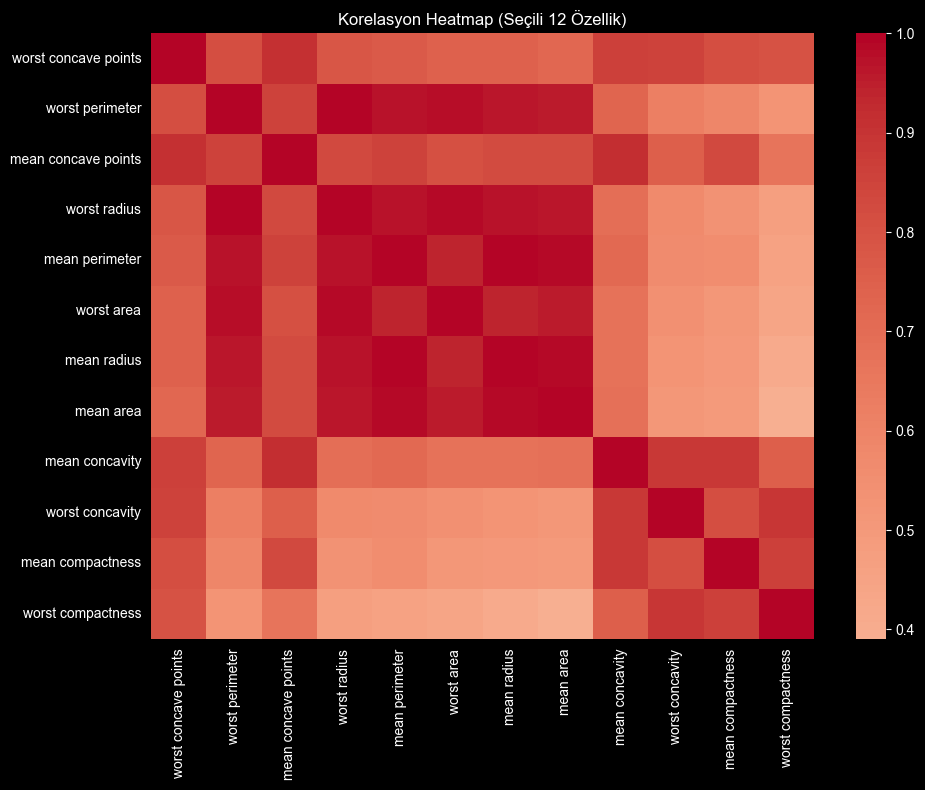

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Tüm özellikler için korelasyon matrisi
korelasyon = X.corr()

# Heatmap çok kalabalık olmasın diye, hedef değişkenle en ilişkili ilk 12 özelliği seçiyorum
hedef_korelasyon = X.corrwith(y).abs().sort_values(ascending=False)
secili_ozellikler = hedef_korelasyon.index[:12]
korelasyon_secili = korelasyon.loc[secili_ozellikler, secili_ozellikler]

plt.figure(figsize=(10, 8))
sns.heatmap(korelasyon_secili, cmap='coolwarm', center=0, annot=False)
plt.title('Korelasyon Heatmap (Seçili 12 Özellik)')
plt.tight_layout()

def repo_kokunu_bul() -> Path:
    # Önce Git reposunun kökünü (.git üzerinden) bulmaya çalışıyorum
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / '.git').exists():
            return p
    # Colab vb. ortamlarda .git olmayabilir; o zaman mevcut dizini kök kabul ediyorum
    return cwd

repo_kok = repo_kokunu_bul()
figures_dir = repo_kok / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
cikis_dosyasi = figures_dir / '03_korelasyon_heatmap.svg'

plt.savefig(cikis_dosyasi)
print('Kaydedildi:', cikis_dosyasi.resolve())
plt.show()


In [24]:
# En yüksek mutlak korelasyona sahip ilk 3 değişken çifti
korelasyon_abs = korelasyon.abs()
ust_ucgen = korelasyon_abs.where(np.triu(np.ones(korelasyon_abs.shape), k=1).astype(bool))
en_yuksek = (
    ust_ucgen.stack()
    .sort_values(ascending=False)
    .head(3)
)
en_yuksek


mean radius   mean perimeter     0.997855
worst radius  worst perimeter    0.993708
mean radius   mean area          0.987357
dtype: float64

## 3. Bölüm Sonu Yorumu

Bu adımda verinin genel dağılımını ve değişkenlerin birbiriyle ilişkisini gördüm. Korelasyon matrisi özellikle
çok benzer bilgi taşıyan özellikleri fark etmeme yardımcı oldu.


# 4. Veri Bölünmesi ve Ölçeklendirme

Bu aşamada veriyi `train / validation / test` olarak ayırıyorum. Daha sonra ölçeklendirmeyi sadece `train` 
verisine göre öğrenip (`fit`), diğerlerine aynı dönüşümü uyguluyorum (`transform`). Böylece veri sızıntısı 
(data leakage) riskini azaltmış olurum.


## 4.1 Train / Validation / Test Bölünmesi (70 / 10 / 20)

Ödevde istenen oranları korumak için önce `%20` test ayırıp, kalan `%80` kısmı kendi içinde `%70` train ve 
%10 validation olacak şekilde tekrar bölüyorum. `stratify=y` ile sınıf oranlarını yaklaşık sabit tutuyorum.


In [26]:
from sklearn.model_selection import train_test_split

# 1) Önce test setini ayır (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2) Kalan 80% içinden validation ve test'i eşit böl (10% + 10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val  :', X_val.shape,   'y_val  :', y_val.shape)
print('X_test :', X_test.shape,  'y_test :', y_test.shape)


X_train: (455, 30) y_train: (455,)
X_val  : (57, 30) y_val  : (57,)
X_test : (57, 30) y_test : (57,)


In [27]:
# Sınıf dağılımları yaklaşık korunuyor mu?
print('train target dağılımı:\n', y_train.value_counts(normalize=True))
print('val   target dağılımı:\n', y_val.value_counts(normalize=True))
print('test  target dağılımı:\n', y_test.value_counts(normalize=True))


train target dağılımı:
 target
1    0.626374
0    0.373626
Name: proportion, dtype: float64
val   target dağılımı:
 target
1    0.631579
0    0.368421
Name: proportion, dtype: float64
test  target dağılımı:
 target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


## 4.2 Ölçeklendirme (StandardScaler)

Özelliklerin ölçekleri farklı olduğu için `StandardScaler` kullanıyorum. En önemli nokta: scaler'ı sadece 
train verisiyle `fit` etmek.


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Kolon isimlerini kaybetmemek için tekrar DataFrame'e çeviriyorum
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=X.columns, index=X_val.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns, index=X_test.index)

X_train_scaled.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
546,-1.072001,-0.658425,-1.088080,-0.939274,-0.135940,-1.008718,-0.968359,-1.102032,0.281062,-0.113231,-0.704861,-0.440938,-0.743949,-0.629805,0.000748,-0.991573,-0.693760,-0.983284,-0.591579,-0.428972,-1.034094,-0.623497,-1.070773,-0.876534,-0.169982,-1.038836,-1.078995,-1.350527,-0.352658,-0.541380
432,1.748743,0.066502,1.751157,1.745559,1.274468,0.842288,1.519852,1.994664,-0.293045,-0.320180,0.127567,-0.381383,0.094075,0.317524,0.639656,0.087389,0.708451,1.182150,0.426212,0.074797,1.228342,-0.092833,1.187467,1.104386,1.517001,0.249655,1.178594,1.549916,0.191078,-0.173739
174,-0.974734,-0.931124,-0.997709,-0.867589,-0.613515,-1.138154,-1.092292,-1.243358,0.434395,-0.429247,-0.254445,1.237130,-0.338634,-0.413827,0.520240,-0.833114,-1.006736,-1.857894,1.356046,-1.006560,-0.973231,-1.036772,-1.008044,-0.834168,-1.097823,-1.167260,-1.282241,-1.707442,-0.307734,-1.213033
221,-0.145103,-1.215186,-0.123013,-0.253192,0.664482,0.286762,-0.129729,-0.098605,0.555635,0.029395,-0.531049,-1.262281,-0.411682,-0.436600,-0.393580,-0.129997,-0.219965,-0.527278,-0.269450,-0.316623,-0.251266,-1.369643,-0.166633,-0.330292,0.234006,0.096874,-0.087521,-0.344838,0.242198,-0.118266
289,-0.771617,-0.081211,-0.803700,-0.732927,-0.672282,-1.006099,-0.798502,-0.684484,0.737495,-0.457213,-0.498529,1.322961,-0.440597,-0.521457,-0.174225,-0.628196,-0.581187,-0.278344,1.528534,-0.313022,-0.801135,0.079230,-0.824381,-0.741830,-0.911367,-0.984612,-0.933190,-0.777604,0.555118,-0.761639


## 4. Bölüm Sonu Yorumu

Bu adımda veriyi 70/10/20 oranında böldüm ve ölçeklendirmeyi sadece train verisine göre öğrenerek uyguladım. 
Böylece sonraki PCA/LDA ve modelleme adımlarına daha sağlıklı bir şekilde geçebilirim.


# 5. PCA (Boyut İndirgeme)

PCA (Principal Component Analysis), değişkenleri daha az sayıda bileşene indirgerken mümkün olduğunca varyansı (bilgiyi) korumaya çalışır.
Bu bölümde PCA’yı sadece `train` verisi üzerinde öğrenip (`fit`), `val` ve `test` verisine aynı dönüşümü uyguluyorum (`transform`).


## 5.1 PCA Bileşen Sayısını Seçme

Ödevde istenen kurala göre, `explained_variance_ratio_` değerleri ortalamanın üstünde olan bileşenleri seçiyorum.


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def repo_kokunu_bul() -> Path:
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / '.git').exists():
            return p
    return cwd

# Önce tüm bileşenlerle PCA öğrenip explained variance oranlarına bakıyorum
pca_tam = PCA(random_state=42)
pca_tam.fit(X_train_scaled)

oranlar = pca_tam.explained_variance_ratio_
esik = oranlar.mean()
secili_bilesen_sayisi = int((oranlar > esik).sum())

print('Bileşen sayısı (toplam):', len(oranlar))
print('Ortalama explained variance oranı:', esik)
print('Seçilen bileşen sayısı:', secili_bilesen_sayisi)


In [ ]:
# Explained variance grafiği (tek tek ve kümülatif)
kumulatif = np.cumsum(oranlar)

fig = plt.figure(figsize=(10, 4))
plt.plot(oranlar, marker='o', linewidth=1, label='Explained variance ratio')
plt.plot(kumulatif, marker='.', linewidth=2, label='Kümülatif')
plt.axhline(esik, color='red', linestyle='--', linewidth=1, label='Ortalama eşik')
plt.title('PCA Explained Variance Oranları')
plt.xlabel('Bileşen indeksi')
plt.ylabel('Oran')
plt.legend()
plt.tight_layout()

repo_kok = repo_kokunu_bul()
figures_dir = repo_kok / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
cikis = figures_dir / '05_pca_explained_variance.svg'
plt.savefig(cikis)
print('Kaydedildi:', cikis.resolve())
plt.show()


## 5.2 PCA Dönüşümü (Train/Val/Test)

Seçtiğim bileşen sayısı ile PCA modelini tekrar eğitip, üç veri setine de aynı dönüşümü uyguluyorum.


In [ ]:
pca = PCA(n_components=secili_bilesen_sayisi, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print('X_train_pca:', X_train_pca.shape)
print('X_val_pca  :', X_val_pca.shape)
print('X_test_pca :', X_test_pca.shape)


## 5.3 PCA 2B Görselleştirme

PCA’yı daha iyi sezmek için ilk iki bileşende 2 boyutlu bir saçılım grafiği çiziyorum (bu grafik sadece görselleştirme amaçlıdır).


In [ ]:
import seaborn as sns

pca_viz = PCA(n_components=2, random_state=42)
X_train_2d = pca_viz.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(X_train_2d, columns=['PC1', 'PC2'], index=y_train.index)
pca_df['target'] = y_train.values

plt.figure(figsize=(7, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='target', palette='Set2', alpha=0.7)
plt.title('PCA 2B Scatter (Train)')
plt.tight_layout()

repo_kok = repo_kokunu_bul()
figures_dir = repo_kok / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
cikis = figures_dir / '05_pca_scatter_train.svg'
plt.savefig(cikis)
print('Kaydedildi:', cikis.resolve())
plt.show()


## 5. Bölüm Sonu Yorumu

PCA ile boyutu düşürerek hem daha kompakt bir temsil elde ettim hem de değişkenler arası yüksek korelasyonların etkisini azaltmaya yaklaştım.
Seçilen bileşen sayısını ödevdeki kurala göre (ortalamanın üstündeki explained variance oranları) belirledim.


# 6. LDA (Sınıf Ayırıcı Boyut İndirgeme)

LDA (Linear Discriminant Analysis), sınıfları ayıran doğrusal kombinasyonları bulmaya çalışır. PCA’dan farkı: etiketi (`y`) kullanır.

Not: İki sınıflı (0/1) bir problemde LDA ile elde edilebilecek maksimum bileşen sayısı `n_classes - 1` olduğu için en fazla **1** bileşen elde edebiliriz.
Bu yüzden burada LDA’yı 1 bileşenle uyguluyorum.


## 6.1 LDA Dönüşümü (Train/Val/Test)

LDA modelini `train` verisinde öğrenip, `val` ve `test` verisine aynı dönüşümü uyguluyorum.


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=1)

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_val_lda   = lda.transform(X_val_scaled)
X_test_lda  = lda.transform(X_test_scaled)

print('X_train_lda:', X_train_lda.shape)
print('X_val_lda  :', X_val_lda.shape)
print('X_test_lda :', X_test_lda.shape)


## 6.2 LDA Görselleştirme (1 Boyut)

LDA çıktısı tek boyut olduğu için, sınıflara göre dağılımı bir histogram/yoğunluk grafiği ile inceliyorum.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

def repo_kokunu_bul() -> Path:
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / '.git').exists():
            return p
    return cwd

lda_df = pd.DataFrame({'LD1': X_train_lda.ravel(), 'target': y_train.values})

plt.figure(figsize=(8, 4))
sns.histplot(data=lda_df, x='LD1', hue='target', stat='density', common_norm=False, bins=30, element='step')
plt.title('LDA Dağılımı (Train)')
plt.tight_layout()

repo_kok = repo_kokunu_bul()
figures_dir = repo_kok / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
cikis = figures_dir / '06_lda_hist_train.svg'
plt.savefig(cikis)
print('Kaydedildi:', cikis.resolve())
plt.show()


## 6. Bölüm Sonu Yorumu

LDA çıktısı tek boyutlu olsa bile, sınıfların bu eksende ne kadar ayrıştığını görmek bize güçlü bir sezgi verir.
İlerleyen adımlarda LDA temsili üzerinde de aynı modelleri deneyip performanslarını karşılaştıracağım.
